In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/trilytics-train/trainData.csv


In [ ]:
train_df = pd.read_csv('/kaggle/input/trilytics-train/trainData.csv')
train_df=train_df.drop(columns=['FarmerID'],axis=1)

In [ ]:
train_df.describe().T.astype('uint64')

,count,mean,std,min,25%,50%,75%,max
Zipcode,47970,486844,120222,122103,445302,483119,521109,855117
No_of_Active_Loan_In_Bureau,47970,1,2,0,0,1,2,62
Avg_Disbursement_Amount_Bureau,27180,246383,711115,0,57902,129097,284025,80000000
Non_Agriculture_Income,47970,280643,1707940,0,0,100000,250000,71282300
Total_Land_For_Agriculture,47899,9,6,0,5,10,12,151
K022-Proximity to nearest mandi (Km),47970,11,7,0,6,10,15,44
K022-Proximity to nearest railway (Km),47970,15,13,0,3,11,23,93
KO22-Village score based on socio-economic parameters (0 to 100),47970,37,7,8,32,37,41,100
K022-Seasonal Average Rainfall (mm),47970,1394,424,530,1057,1375,1687,2569
R022-Seasonal Average Rainfall (mm),47970,139,109,17,63,103,175,733


In [ ]:
missing = train_df.isnull().sum()
missing = missing[missing > 0]
print(missing)

Location                                                        17030
Address type                                                    17030
Ownership                                                       17030
Avg_Disbursement_Amount_Bureau                                  20790
Total_Land_For_Agriculture                                         71
Perc_of_house_with_6plus_room                                     168
Women_15_19_Mothers_or_Pregnant_at_time_of_survey                 168
perc_of_pop_living_in_hh_electricity                              168
perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms       168
mat_roof_Metal_GI_Asbestos_sheets                                 168
perc_of_Wall_material_with_Burnt_brick                            168
Households_with_improved_Sanitation_Facility                      168
perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k      168
dtype: int64


In [ ]:
cols_to_clean = ['Total_Land_For_Agriculture', 'Perc_of_house_with_6plus_room', 'Women_15_19_Mothers_or_Pregnant_at_time_of_survey', 'perc_of_pop_living_in_hh_electricity', 'perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms', 'mat_roof_Metal_GI_Asbestos_sheets', 'perc_of_Wall_material_with_Burnt_brick', 'Households_with_improved_Sanitation_Facility', 'perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k']
train_df = train_df.dropna(subset=cols_to_clean)

train_df['Avg_Disbursement_Amount_Bureau'] = train_df['Avg_Disbursement_Amount_Bureau'].fillna(0)

In [ ]:
train_df = train_df.drop(columns = ['Location', 'Address type', 'Ownership'], axis = 1)

In [ ]:
missing = train_df.isnull().sum()
missing = missing[missing > 0]
print(missing)

Series([], dtype: int64)


In [ ]:
train_df['Zipcode']=train_df['Zipcode'].astype('object')

In [ ]:
temp_cols = [
    'K021-Ambient temperature (min & max)',
    'K022-Ambient temperature (min & max)',
    'R020-Ambient temperature (min & max)',
    'R021-Ambient temperature (min & max)',
    'R022-Ambient temperature (min & max)'
]

for col in temp_cols:
    base = col.split('-')[0]

    train_df[[f'{base}_temp_min', f'{base}_temp_max']] = train_df[col].str.split('/', expand=True)

    train_df[f'{base}_temp_min'] = pd.to_numeric(train_df[f'{base}_temp_min'], errors='coerce')
    train_df[f'{base}_temp_max'] = pd.to_numeric(train_df[f'{base}_temp_max'], errors='coerce')

train_df = train_df.drop(columns=temp_cols, axis = 1)


In [ ]:
cat_col = train_df.select_dtypes(include=['object']).columns

for cols in cat_col:
    print(cols, f'[{len(train_df[cols].unique())}]')

#high cardinality cat features city, district, village, K022-Nearest Mandi Name... target-encoding, remaining try label encoding nd ohc both

State [16]
REGION [5]
SEX [2]
CITY [2685]
Zipcode [4439]
DISTRICT [398]
VILLAGE [5643]
MARITAL_STATUS [2]
K022-Village category based on Agri parameters (Good, Average, Poor) [2]
K022-Nearest Mandi Name [890]
K022-Village category based on socio-economic parameters (Good, Average, Poor) [3]
R022-Village category based on Agri parameters (Good, Average, Poor) [2]
Kharif Seasons  Type of soil in 2022 [8]
Kharif Seasons  Type of water bodies in hectares 2022 [22]
Kharif Seasons  Agro Ecological Sub Zone in 2022 [12]
Rabi Seasons Type of soil in 2022 [8]
Rabi Seasons Type of water bodies in hectares 2022 [22]
Rabi Seasons Agro Ecological Sub Zone in 2022 [12]
Rabi Seasons Type of soil in 2021 [8]
Rabi Seasons Type of water bodies in hectares 2021 [22]
Rabi Seasons Agro Ecological Sub Zone in 2021 [12]
Kharif Seasons Type of soil in 2021 [8]
Kharif Seasons Type of water bodies in hectares 2021 [22]
Kharif Seasons Agro Ecological Sub Zone in 2021 [12]
Kharif Seasons Type of soil in 2020 [8]


In [ ]:
cat_col = train_df.select_dtypes(include=['object']).columns
num_col = train_df.select_dtypes(include=['number']).columns
print(len(cat_col), len(num_col))

31 75


In [ ]:
pd.set_option('display.max_rows', None)
skewness = train_df[num_col].skew().sort_values(ascending=False)
print(skewness)

Avg_Disbursement_Amount_Bureau                                                  78.767838
Non_Agriculture_Income                                                          26.561974
Target_Variable/Total Income                                                    23.085319
 Land Holding Index source (Total Agri Area/ no of people)                      13.832062
 Road density (Km/ SqKm)                                                         6.487517
No_of_Active_Loan_In_Bureau                                                      3.040458
K022-Total Geographical Area (in Hectares)-                                      2.815984
K022-Net Agri area (in Ha)-                                                      2.783613
Total_Land_For_Agriculture                                                       2.714196
Perc_of_house_with_6plus_room                                                    2.567578
perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms                      2.159163
perc_House

In [ ]:
log_transformed = []

for col in num_col:
    skew_val = skewness[col]

    if abs(skew_val) >= 1.5:
            # Log transform moderately skewed features
            train_df[f'{col}_log'] = np.log1p(train_df[col])
            train_df.drop(columns=[col], inplace=True)
            log_transformed.append(col)
            print(f"Log transformed {col} due to skewness: {skew_val:.2f}")

print("\nSummary:")
print(f"Log transformed features ({len(log_transformed)}): {log_transformed}")

Log transformed No_of_Active_Loan_In_Bureau due to skewness: 3.04
Log transformed Avg_Disbursement_Amount_Bureau due to skewness: 78.77
Log transformed Non_Agriculture_Income due to skewness: 26.56
Log transformed Total_Land_For_Agriculture due to skewness: 2.71
Log transformed R022-Seasonal Average Rainfall (mm) due to skewness: 1.63
Log transformed R020-Seasonal Average Rainfall (mm) due to skewness: 1.92
Log transformed Perc_of_house_with_6plus_room due to skewness: 2.57
Log transformed perc_of_pop_living_in_hh_electricity due to skewness: -4.90
Log transformed perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms due to skewness: 2.16
Log transformed mat_roof_Metal_GI_Asbestos_sheets due to skewness: 1.53
Log transformed perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k due to skewness: 2.14
Log transformed K022-Total Geographical Area (in Hectares)- due to skewness: 2.82
Log transformed K022-Net Agri area (in Ha)- due to skewness: 2.78
Log transformed  Night light

In [ ]:
cat_col = train_df.select_dtypes(include=['object']).columns
num_col = train_df.select_dtypes(include=['number']).columns
print(len(cat_col), len(num_col))

31 75


In [ ]:
skewness = train_df[num_col].skew().sort_values(ascending=False)
print(skewness)

 Land Holding Index source (Total Agri Area/ no of people)_log                  3.260457
Target_Variable/Total Income_log                                                1.685610
Women_15_19_Mothers_or_Pregnant_at_time_of_survey                               1.323348
R021-Seasonal Average Rainfall (mm)                                             1.260493
Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2022       1.253730
K022-Proximity to nearest railway (Km)                                          1.060863
 Road density (Km/ SqKm)_log                                                    0.903100
K022-Proximity to nearest mandi (Km)                                            0.813939
Kharif Seasons Agricultural performance in 2021                                 0.805974
No_of_Active_Loan_In_Bureau_log                                                 0.724184
Perc_of_house_with_6plus_room_log                                               0.635642
perc_Households_do_no

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# n_cols = 3
# n_rows = (len(num_col) + n_cols - 1) // n_cols

# plt.figure(figsize=(5*n_cols, 4*n_rows))

# for i, col in enumerate(num_col):
#     plt.subplot(n_rows, n_cols, i + 1)

#     data = train_df[col].replace([np.inf, -np.inf], np.nan)
#     plt.hist(data, bins=50, alpha=0.6, density=True)

#     # Plot KDE with seaborn
#     sns.kdeplot(data, bw_adjust=2)  # adjust bw as needed for smoothness

#     plt.title(col)

# plt.tight_layout()
# plt.show()

In [ ]:
# corr= train_df[num_col].corr()

# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(20,18)) # Adjust figure size as needed
# sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
# plt.title('Correlation Matrix Heatmap')
# plt.show()

In [ ]:
high_cardinal=['Zipcode','CITY', 'DISTRICT', 'VILLAGE','K022_Nearest_Mandi_Name']

# dropped_cats = []

# # Thresholds
# dominant_thresh = 0.95  # if top category >95%, drop

# for col in cat_col:
#     print(f"\nAnalyzing {col}...")

#     # Unique count and dominant frequency
#     n_unique = train_df[col].nunique()
#     freq = train_df[col].value_counts(normalize=True)
#     top_freq = freq.iloc[0]

#     print(f"Unique values: {n_unique}, Top category freq: {top_freq:.2f}")

#     # Skip plots for high cardinality features
#     if col not in high_cardinal:
#         # Plot distribution
#         plt.figure(figsize=(10,4))
#         sns.countplot(x=col, data=train_df, order=train_df[col].value_counts().index)
#         plt.title(f'Distribution of {col}')
#         plt.xticks(rotation=45, ha='right')
#         plt.tight_layout()
#         plt.show()

#         # Plot boxplot vs target
#         plt.figure(figsize=(10,4))
#         sns.boxplot(x=col, y='Target_Variable/Total Income_log', data=train_df)
#         plt.title(f'{col} vs Income')
#         plt.xticks(rotation=45, ha='right')
#         plt.tight_layout()
#         plt.show()
#     else:
#         print(f"> Skipped plotting for high-cardinality feature: {col}")

#     # Drop if near constant
#     if top_freq >= dominant_thresh:
#         train_df.drop(columns=[col], inplace=True)
#         dropped_cats.append(col)
#         print(f"> Dropped {col} due to dominance of single category.")
#         continue

# # Summary
# print("\n=== Categorical EDA Summary ===")
# print(f"Dropped categorical features ({len(dropped_cats)}): {dropped_cats}")


In [ ]:
train_df.columns = train_df.columns.str.replace(r'[^\w]', '_', regex=True)

In [ ]:
cat_col = train_df.select_dtypes(include=['object']).columns

num_col = train_df.select_dtypes(include=['number']).columns

print(len(cat_col), len(num_col))

31 75


In [ ]:
train_df.to_csv('train_clean.csv')

In [ ]:
from sklearn.preprocessing import LabelEncoder

train_df_le=train_df.copy()



from category_encoders import TargetEncoder

te=TargetEncoder(smoothing=2)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error

# Define X and y
X = train_df_le.drop(columns='Target_Variable_Total_Income_log', axis=1)  # or your final processed feature list
y = train_df_le['Target_Variable_Total_Income_log']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

for col in cat_col:
    if col not in high_cardinal:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col])


for cols in high_cardinal:
    X_train[cols] = te.fit_transform(X_train[cols], y_train)
    X_test[cols] = te.transform(X_test[cols])

In [ ]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=42,
        verbosity=0
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=42,
        verbose=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        subsample=0.8,
        colsample_bylevel=0.8,
        random_state=42,
        verbose=0
    ),

    "HistGBR": HistGradientBoostingRegressor(
        max_iter=1000,
        learning_rate=0.05,
        max_depth=6,
        l2_regularization=1.0,
        random_state=42
    )
}


Training RandomForest...
RandomForest MAPE: 0.2358

Training ExtraTrees...
ExtraTrees MAPE: 0.2581

Training XGBoost...
XGBoost MAPE: 0.2110

Training LightGBM...
LightGBM MAPE: 0.2089

Training CatBoost...
CatBoost MAPE: 0.2151

Training HistGBR...
HistGBR MAPE: 0.2192

=== Model Comparison (MAPE) ===
LightGBM: 0.2089
XGBoost: 0.2110
CatBoost: 0.2151
HistGBR: 0.2192
RandomForest: 0.2358
ExtraTrees: 0.2581


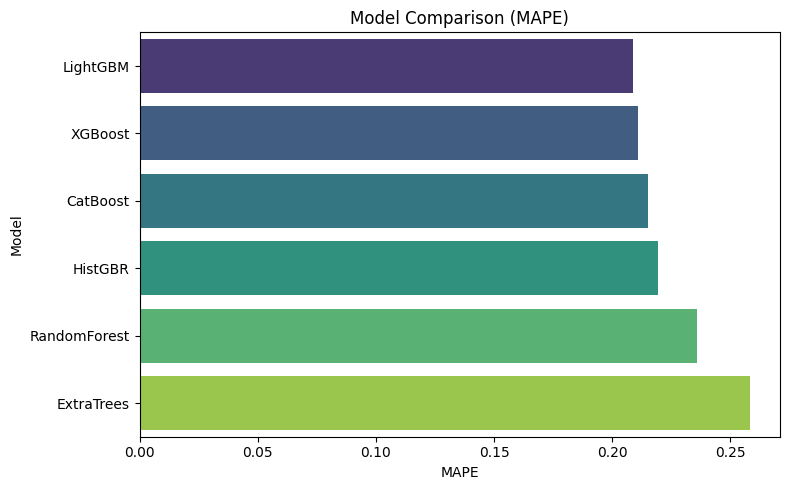

In [ ]:
results={}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_original = np.expm1(y_pred)
    y_test_original = np.expm1(y_test)
    mape = mean_absolute_percentage_error(y_test_original, y_pred_original)
    results[name] = mape
    print(f"{name} MAPE: {mape:.4f}")

# Display comparison
print("\n=== Model Comparison (MAPE) ===")
for name, mape in sorted(results.items(), key=lambda x: x[1]):
    print(f"{name}: {mape:.4f}")

results_series = pd.Series(results).sort_values()

plt.figure(figsize=(8,5))
sns.barplot(x=results_series.values, y=results_series.index, palette="viridis")

plt.title("Model Comparison (MAPE)")
plt.xlabel("MAPE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [ ]:
import optuna

final_results = {}

def tune_xgb(X_train, y_train, X_test, y_test, n_trials=50):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 500, 1500),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
            "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
            "n_jobs": -1,
            "random_state": 42
        }
        model = XGBRegressor(**params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_original = np.expm1(y_pred)
        y_test_original = np.expm1(y_test)
        return mean_absolute_percentage_error(y_test_original, y_pred_original)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)
    print("XGBoost Best Params:", study.best_params)
    final_results['XGBoost'] = study.best_value

def tune_lgbm(X_train, y_train, X_test, y_test, n_trials=50):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 500, 1500),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
            "num_leaves": trial.suggest_int("num_leaves", 20, 100),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
            "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
            "n_jobs": -1,
            "random_state": 42,
            "verbose":-1
        }
        model = LGBMRegressor(**params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_original = np.expm1(y_pred)
        y_test_original = np.expm1(y_test)
        return mean_absolute_percentage_error(y_test_original, y_pred_original)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)
    print("LightGBM Best Params:", study.best_params)
    final_results['LightGBM'] = study.best_value

def tune_catboost(X_train, y_train, X_test, y_test, n_trials=15):
    def objective(trial):
        params = {
            "iterations": trial.suggest_int("iterations", 500, 1500),
            "depth": trial.suggest_int("depth", 3, 10),
            "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
            "random_strength": trial.suggest_float("random_strength", 0, 1),
            "random_state": 42,
            "verbose": 0
        }
        model = CatBoostRegressor(**params)
        model.fit(X_train, y_train)
        y_pred_original = np.expm1(y_pred)
        y_test_original = np.expm1(y_test)
        return mean_absolute_percentage_error(y_test_original, y_pred_original)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)
    print("CatBoost Best Params:", study.best_params)
    final_results['CatBoost'] = study.best_value

tune_lgbm(X_train, y_train, X_test, y_test)

print("\n=== Final tuned MAPEs ===")
for model, mape in final_results.items():
    print(f"{model}: {mape:.4f}")


[I 2025-07-26 17:09:58,187] A new study created in memory with name: no-name-fcc15361-7a95-41d8-a4f4-ed102a4ba39a
[I 2025-07-26 17:10:10,328] Trial 0 finished with value: 0.21742749595259464 and parameters: {'n_estimators': 1422, 'max_depth': 11, 'learning_rate': 0.16370199791574735, 'num_leaves': 46, 'subsample': 0.8740914818557508, 'colsample_bytree': 0.717530559118529, 'reg_alpha': 2.8762415682639886, 'reg_lambda': 2.652094143261027}. Best is trial 0 with value: 0.21742749595259464.
[I 2025-07-26 17:10:21,229] Trial 1 finished with value: 0.21481996413315402 and parameters: {'n_estimators': 1284, 'max_depth': 7, 'learning_rate': 0.038278400631702694, 'num_leaves': 34, 'subsample': 0.8188304341662147, 'colsample_bytree': 0.8082141435796574, 'reg_alpha': 2.810925429433697, 'reg_lambda': 0.36918373153119965}. Best is trial 1 with value: 0.21481996413315402.
[I 2025-07-26 17:10:25,862] Trial 2 finished with value: 0.22527915516370645 and parameters: {'n_estimators': 1265, 'max_depth': 3

LightGBM Best Params: {'n_estimators': 1125, 'max_depth': 12, 'learning_rate': 0.027279215076200437, 'num_leaves': 84, 'subsample': 0.917483006064144, 'colsample_bytree': 0.6503965303417031, 'reg_alpha': 0.032621588142396796, 'reg_lambda': 3.9328951989104786}

=== Final tuned MAPEs ===
LightGBM: 0.2106


In [ ]:
train_df_ohe=train_df.copy()

#split->standardscaler->ohe

#LR, lasoo ridge elastic GAm
X = train_df_ohe.drop(columns='Target_Variable/Total Income_log', axis=1)  # or your final processed feature list
y = train_df_ohe['Target_Variable/Total Income_log']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

te=TargetEncoder(smoothing=5)
for cols in high_cardinal:
    X_train[cols] = te.fit_transform(X_train[cols], y_train)
    X_test[cols] = te.transform(X_test[cols])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

num_col = list(num_col)
high_cardinal = list(high_cardinal)
num_te_col = num_col + high_cardinal

num_te_col = [col for col in num_te_col if col != 'Target_Variable/Total Income_log']

X_train[num_te_col]=scaler.fit_transform(X_train[num_te_col])
X_test[num_te_col]=scaler.transform(X_test[num_te_col])


In [ ]:
#dummies
combined = pd.concat([X_train, X_test], keys=['train', 'test'])

combined_encoded = pd.get_dummies(combined, drop_first=True)

X_train= combined_encoded.xs('train')
X_test = combined_encoded.xs('test')

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_percentage_error

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet()
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_pred_original = np.expm1(y_pred)
    y_test_original = np.expm1(y_test)

    mape = mean_absolute_percentage_error(y_test_original, y_pred_original)
    results[name] = mape
    print(f"{name} MAPE: {mape:.4f}")

# Print final comparison
print("\n=== Linear model MAPEs ===")
for name, mape in sorted(results.items(), key=lambda x: x[1]):
    print(f"{name}: {mape:.4f}")



Training LinearRegression...
LinearRegression MAPE: 0.2816

Training Ridge...
Ridge MAPE: 0.2780

Training Lasso...
Lasso MAPE: 0.3636

Training ElasticNet...
ElasticNet MAPE: 0.3636

=== Linear model MAPEs ===
Ridge: 0.2780
LinearRegression: 0.2816
Lasso: 0.3636
ElasticNet: 0.3636


In [ ]:
import optuna

final_results = {}

def objective_ridge(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-3, 1e3)
    model = Ridge(alpha=alpha, max_iter=10000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_pred_original = np.expm1(y_pred)
    y_test_original = np.expm1(y_test)

    return mean_absolute_percentage_error(y_test_original, y_pred_original)


def objective_lasso(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-3, 1e2)
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_pred_original = np.expm1(y_pred)
    y_test_original = np.expm1(y_test)

    return mean_absolute_percentage_error(y_test_original, y_pred_original)


def objective_elastic(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-3, 1e2)
    l1_ratio = trial.suggest_float('l1_ratio', 0.1, 0.9)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_pred_original = np.expm1(y_pred)
    y_test_original = np.expm1(y_test)

    return mean_absolute_percentage_error(y_test_original, y_pred_original)


models = {
    "Ridge": objective_ridge,
    "Lasso": objective_lasso,
    "ElasticNet": objective_elastic
}

for name, obj in models.items():
    print(f"\n Tuning {name}...")
    study = optuna.create_study(direction="minimize")
    study.optimize(obj, n_trials=30)

    print(f"{name} best params:", study.best_params)
    print(f"{name} best MAPE: {study.best_value:.4f}")

    final_results[name] = (study.best_params, study.best_value)


print("\n=== Final Tuned Linear Model MAPEs ===")
for model, (params, mape) in final_results.items():
    print(f"{model}: {mape:.4f}, params: {params}")

[I 2025-07-26 17:37:27,418] A new study created in memory with name: no-name-d3fe830c-807b-4afe-8d43-6b1de347355d



 Tuning Ridge...


[I 2025-07-26 17:37:27,640] Trial 0 finished with value: 0.2780162197568365 and parameters: {'alpha': 109.53393304075068}. Best is trial 0 with value: 0.2780162197568365.
[I 2025-07-26 17:37:27,866] Trial 1 finished with value: 0.2779596009280093 and parameters: {'alpha': 2.813727271977795}. Best is trial 1 with value: 0.2779596009280093.
[I 2025-07-26 17:37:28,091] Trial 2 finished with value: 0.27801707568935546 and parameters: {'alpha': 0.018448991275164948}. Best is trial 1 with value: 0.2779596009280093.
[I 2025-07-26 17:37:28,319] Trial 3 finished with value: 0.2780858718184369 and parameters: {'alpha': 158.8685403589541}. Best is trial 1 with value: 0.2779596009280093.
[I 2025-07-26 17:37:28,527] Trial 4 finished with value: 0.27802356736933426 and parameters: {'alpha': 0.16473272123518942}. Best is trial 1 with value: 0.2779596009280093.
[I 2025-07-26 17:37:28,741] Trial 5 finished with value: 0.27809651936564733 and parameters: {'alpha': 166.56619539484498}. Best is trial 1 wi

Ridge best params: {'alpha': 20.15837551980879}
Ridge best MAPE: 0.2779

 Tuning Lasso...


[I 2025-07-26 17:37:34,661] Trial 0 finished with value: 0.2797953377116475 and parameters: {'alpha': 0.0048612001920869665}. Best is trial 0 with value: 0.2797953377116475.
[I 2025-07-26 17:37:35,179] Trial 1 finished with value: 0.34892452832576576 and parameters: {'alpha': 0.19954925002428642}. Best is trial 0 with value: 0.2797953377116475.
[I 2025-07-26 17:37:35,799] Trial 2 finished with value: 0.2792840698010358 and parameters: {'alpha': 0.0030330582559218583}. Best is trial 2 with value: 0.2792840698010358.
[I 2025-07-26 17:37:36,418] Trial 3 finished with value: 0.28399673897465677 and parameters: {'alpha': 0.023995082274851132}. Best is trial 2 with value: 0.2792840698010358.
[I 2025-07-26 17:37:36,900] Trial 4 finished with value: 0.3635931983411062 and parameters: {'alpha': 33.96457088305741}. Best is trial 2 with value: 0.2792840698010358.
[I 2025-07-26 17:37:37,515] Trial 5 finished with value: 0.2836126305472605 and parameters: {'alpha': 0.02053242152523803}. Best is tri

Lasso best params: {'alpha': 0.0010124293398841547}
Lasso best MAPE: 0.2785

 Tuning ElasticNet...


[I 2025-07-26 17:37:55,469] Trial 0 finished with value: 0.27838071984594803 and parameters: {'alpha': 0.00244190973570375, 'l1_ratio': 0.3374661141338333}. Best is trial 0 with value: 0.27838071984594803.
[I 2025-07-26 17:37:56,014] Trial 1 finished with value: 0.2909437550747681 and parameters: {'alpha': 0.12426292029232394, 'l1_ratio': 0.3854837472554704}. Best is trial 0 with value: 0.27838071984594803.
[I 2025-07-26 17:37:56,592] Trial 2 finished with value: 0.28132693922044866 and parameters: {'alpha': 0.03204904930792135, 'l1_ratio': 0.24457839517128335}. Best is trial 0 with value: 0.27838071984594803.
[I 2025-07-26 17:37:57,049] Trial 3 finished with value: 0.3635931983411062 and parameters: {'alpha': 2.755132679475988, 'l1_ratio': 0.8580663613044849}. Best is trial 0 with value: 0.27838071984594803.
[I 2025-07-26 17:37:57,502] Trial 4 finished with value: 0.3635931983411062 and parameters: {'alpha': 0.41140087378303747, 'l1_ratio': 0.7996201757793725}. Best is trial 0 with va

ElasticNet best params: {'alpha': 0.001190090100294462, 'l1_ratio': 0.13260048609086164}
ElasticNet best MAPE: 0.2779

=== Final Tuned Linear Model MAPEs ===
Ridge: 0.2779, params: {'alpha': 20.15837551980879}
Lasso: 0.2785, params: {'alpha': 0.0010124293398841547}
ElasticNet: 0.2779, params: {'alpha': 0.001190090100294462, 'l1_ratio': 0.13260048609086164}


In [ ]:
ridge_params = {'alpha': 20.15837551980879}
elastic_params={'alpha': 0.001190090100294462, 'l1_ratio': 0.13260048609086164}
# Ridge: 0.2779, params: {'alpha': 20.15837551980879}
# Lasso: 0.2785, params: {'alpha': 0.0010124293398841547}
# ElasticNet: 0.2779, params: {'alpha': 0.001190090100294462, 'l1_ratio': 0.13260048609086164}
ridge=Ridge(**ridge_params).fit(X_train, y_train)
elastic=ElasticNet(**elastic_params).fit(X_train, y_train)

pred_ridge=ridge.predict(X_test)
pred_elastic=elastic.predict(X_test)
pred_ridge = np.expm1(pred_ridge)
pred_elastic = np.expm1(pred_elastic)


In [ ]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 65.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvi

In [ ]:
train_df_tabnet=train_df.copy()

X = train_df_tabnet.drop(columns='Target_Variable/Total Income_log', axis=1)  # or your final processed feature list
y = train_df_tabnet['Target_Variable/Total Income_log']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

te=TargetEncoder(smoothing=5)
for cols in high_cardinal:
    X_train[cols] = te.fit_transform(X_train[cols], y_train)
    X_test[cols] = te.transform(X_test[cols])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

num_col = list(num_col)
high_cardinal = list(high_cardinal)
num_te_col = num_col + high_cardinal

num_te_col = [col for col in num_te_col if col != 'Target_Variable/Total Income_log']

X_train[num_te_col]=scaler.fit_transform(X_train[num_te_col])
X_test[num_te_col]=scaler.transform(X_test[num_te_col])



for col in cat_col:
    if col not in high_cardinal:
        le=LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col])

cat_col=list(cat_col)
cat_col=[col for col in cat_col if col not in high_cardinal]

from pytorch_tabnet.tab_model import TabNetRegressor
import torch

cat_idxs = [X_train.columns.get_loc(col) for col in cat_col]
cat_dims = [X_train[col].nunique() for col in cat_col]

model = TabNetRegressor(
    n_d=64, n_a=64, n_steps=5,         # model capacity
    gamma=1.5,                         # feature reuse factor
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=16,                     # small embedding size
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-3),
    mask_type='sparsemax',             # or 'entmax'
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=10
)

model.fit(
    X_train.values, y_train.values.reshape(-1, 1),
    eval_set=[
        (X_train.values, y_train.values.reshape(-1, 1)),
        (X_test.values, y_test.values.reshape(-1, 1))
    ],
    eval_name=['train','valid'],
    eval_metric=['rmse'],
    max_epochs=200,
    batch_size=1024,
    virtual_batch_size=128,            # for Ghost BatchNorm
    patience=10                        # early stopping
)

y_pred = model.predict(X_test.values)

# Inverse log transform
y_pred_original = np.expm1(y_pred)
y_test_original = np.expm1(y_test)

mape = mean_absolute_percentage_error(y_test_original, y_pred_original)
print("TabNet MAPE:", mape)

epoch 0  | loss: 90.59524| train_rmse: 8.07663 | valid_rmse: 8.06554 |  0:00:05s
epoch 10 | loss: 0.50207 | train_rmse: 0.60081 | valid_rmse: 0.60492 |  0:00:44s
epoch 20 | loss: 0.31657 | train_rmse: 0.51546 | valid_rmse: 0.51724 |  0:01:24s
epoch 30 | loss: 0.29302 | train_rmse: 0.52135 | valid_rmse: 0.52322 |  0:02:03s
epoch 40 | loss: 0.27225 | train_rmse: 0.48517 | valid_rmse: 0.48827 |  0:02:43s
epoch 50 | loss: 0.24469 | train_rmse: 0.46362 | valid_rmse: 0.47084 |  0:03:24s
epoch 60 | loss: 0.23086 | train_rmse: 0.45628 | valid_rmse: 0.46025 |  0:04:05s
epoch 70 | loss: 0.22334 | train_rmse: 0.44974 | valid_rmse: 0.45479 |  0:04:44s
epoch 80 | loss: 0.20936 | train_rmse: 0.43853 | valid_rmse: 0.4459  |  0:05:25s
epoch 90 | loss: 0.19897 | train_rmse: 0.4296  | valid_rmse: 0.43796 |  0:06:05s
epoch 100| loss: 0.19323 | train_rmse: 0.42551 | valid_rmse: 0.43534 |  0:06:46s
epoch 110| loss: 0.17859 | train_rmse: 0.40621 | valid_rmse: 0.41489 |  0:07:27s
epoch 120| loss: 0.17714 | t

In [ ]:
#ensemblin our tree based models
# CatBoost Best Params: {'iterations': 584, 'depth': 8, 'learning_rate': 0.04025938960114845, 'l2_leaf_reg': 2.50676650861405, 'bagging_temperature': 0.5731834688498633, 'random_strength': 0.25035970120220474}
# LightGBM Best Params: {'n_estimators': 1146, 'max_depth': 8, 'learning_rate': 0.08804242460904706, 'num_leaves': 32, 'subsample': 0.8210055177760637, 'colsample_bytree': 0.7923075806873575, 'reg_alpha': 1.6031430885300435, 'reg_lambda': 2.30704220771013}
# XGBoost Best Params: {'n_estimators': 1270, 'max_depth': 11, 'learning_rate': 0.011006667382895165, 'subsample': 0.6123629752258398, 'colsample_bytree': 0.9905728292600275, 'gamma': 0.052117942141420404, 'reg_alpha': 1.5318268073194417, 'reg_lambda': 4.998996385224297}

train_df_ens=train_df.copy()

X = train_df_ens.drop(columns='Target_Variable/Total Income_log', axis=1)  # or your final processed feature list
y = train_df_ens['Target_Variable/Total Income_log']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

for col in cat_col:
    if col not in high_cardinal:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col])

te=TargetEncoder(smoothing=2)
for cols in high_cardinal:
    X_train[cols] = te.fit_transform(X_train[cols], y_train)
    X_test[cols] = te.transform(X_test[cols])

#lgbm needs feature names without special chars
X_train.columns = X_train.columns.str.replace(r'[^\w]', '_', regex=True)
X_test.columns = X_test.columns.str.replace(r'[^\w]', '_', regex=True)

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
#XGBoost Best Params: {'n_estimators': 734, 'max_depth': 12, 'learning_rate': 0.02480733070286038, 'subsample': 0.8366037339782361, 'colsample_bytree': 0.7703809778655555, 'gamma': 0.011391381940922318, 'reg_alpha': 1.4254888968959565, 'reg_lambda': 1.381930394121568}
#LightGBM Best Params: {'n_estimators': 1125, 'max_depth': 12, 'learning_rate': 0.027279215076200437, 'num_leaves': 84, 'subsample': 0.917483006064144, 'colsample_bytree': 0.6503965303417031, 'reg_alpha': 0.032621588142396796, 'reg_lambda': 3.9328951989104786}
lgbm_params = {'n_estimators': 1125, 'max_depth': 12, 'learning_rate': 0.027279215076200437, 'num_leaves': 84, 'subsample': 0.917483006064144, 'colsample_bytree': 0.6503965303417031, 'reg_alpha': 0.032621588142396796, 'reg_lambda': 3.9328951989104786}


xgb_params = {'n_estimators': 734, 'max_depth': 12, 'learning_rate': 0.02480733070286038, 'subsample': 0.8366037339782361, 'colsample_bytree': 0.7703809778655555, 'gamma': 0.011391381940922318, 'reg_alpha': 1.4254888968959565, 'reg_lambda': 1.381930394121568}

xgb = XGBRegressor(**xgb_params).fit(X_train, y_train)
lgbm = LGBMRegressor(**lgbm_params).fit(X_train, y_train)


pred_xgb = xgb.predict(X_test)
pred_lgbm = lgbm.predict(X_test)

y_true = np.expm1(y_test)  # if you used log target
pred_xgb = np.expm1(pred_xgb)
pred_lgbm = np.expm1(pred_lgbm)


In [ ]:
import optuna


def objective(trial):
    # Suggest *unnormalized* weights
    w1 = trial.suggest_float("w1", 0.01, 5.0)
    w2 = trial.suggest_float("w2", 0.01, 5.0)
    w3 = trial.suggest_float("w3", 0.01, 5.0)
    w4 = trial.suggest_float("w4", 0.01, 5.0)

    # Normalize
    total = w1 + w2 + w3 + w4
    w1 /= total
    w2 /= total
    w3 /= total
    w4 /= total

    ensemble_pred = (
        w1 * pred_xgb +
        w2 * pred_lgbm +
        w3 * pred_ridge +
        w4 * pred_elastic
    )

    score = mean_absolute_percentage_error(y_true, ensemble_pred)
    return score

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200)

best_weights = study.best_params
print("Best Weights:", best_weights)
print("Best MAPE:", study.best_value)

[I 2025-07-26 17:54:04,587] A new study created in memory with name: no-name-65b1473e-8292-43bb-8e5b-4789bce47685
[I 2025-07-26 17:54:04,592] Trial 0 finished with value: 0.2337992465487837 and parameters: {'w1': 3.918544598741371, 'w2': 2.88604494488086, 'w3': 2.779255383822153, 'w4': 3.861359837801705}. Best is trial 0 with value: 0.2337992465487837.
[I 2025-07-26 17:54:04,594] Trial 1 finished with value: 0.22056348596165057 and parameters: {'w1': 1.4663395030566981, 'w2': 3.3945316535526335, 'w3': 0.21059458395764785, 'w4': 1.8595951575394247}. Best is trial 1 with value: 0.22056348596165057.
[I 2025-07-26 17:54:04,596] Trial 2 finished with value: 0.2529212951826861 and parameters: {'w1': 0.6339384784186072, 'w2': 2.5266027979589865, 'w3': 4.287456137929953, 'w4': 3.8684475846967095}. Best is trial 1 with value: 0.22056348596165057.
[I 2025-07-26 17:54:04,598] Trial 3 finished with value: 0.23391593301063532 and parameters: {'w1': 0.6892511627616531, 'w2': 1.0976430145782958, 'w3'

Best Weights: {'w1': 1.7836011923006025, 'w2': 4.603946619367635, 'w3': 0.011471725236479772, 'w4': 0.4817206605258527}
Best MAPE: 0.21130326728847962
